# Consolidate all the file in the various directories into a single data frame

## Setup

In [1]:
from pathlib import Path
from datasets import load_dataset, VerificationMode
from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
base = Path(".").resolve() / "eval-all" / "data"
assert base.is_dir() and base.exists()
base

PosixPath('/workspaces/ts-qa/eval-all/data')

## Load the dataset

In [ ]:
# Somehow this is necessary
splits = ["train", "val", "test"]
options = dict(verification_mode=VerificationMode.NO_CHECKS)

# Only download these splits
# splits = ["val", "test"]
# options = dict(
#     **options, data_files={split: f"{split}-*" for split in splits},
# )

ds_binary = load_dataset(
    "dasyd/time-qa",
    "binary",
    data_dir="binary",
    **options,
)
ds_multi = load_dataset(
    "dasyd/time-qa",
    "multi",
    data_dir="multi",
    **options,
)
ds_open = load_dataset(
    "dasyd/time-qa",
    "open",
    data_dir="open",
    **options,
)

hi


In [4]:
concat_dataset = (
    pd.concat(
        [
            ds.remove_columns("trajectory").to_pandas()
            for ds_dict in [ds_binary, ds_multi, ds_open]
            for ds in ds_dict.values()
        ],
        ignore_index=True,
    )
    .set_index(["sample_id", "question_id"])
    .sort_index()
)
concat_dataset

action_sequence  \
sample_id question_id                                                      
0         0            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          1            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          2            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          3            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          4            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
...                                                                  ...   
29999     0            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          1            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          2            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          3            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   
          4            {'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...   

                                                     textual_description  \
sample_id question_id                                                      
0         0            The person is starting the sequence with holdi...   
          1            The person is starting the sequence with holdi...   
          2            The person is starting the sequence with holdi...   
          3            The person is starting the sequence with holdi...   
          4            The person is starting the sequence with holdi...   
...                                                                  ...   
29999     0            The sequence starts with picking something up ...   
          1            The sequence starts with picking something up ...   
          2            The sequence starts with picking something up ...   
          3            The sequence starts with picking something up ...   
          4            The sequence starts with picking something up ...   

                                           question_type  \
sample_id question_id                                      
0         0                                   count_open   
          1                            right_after_multi   
          2                                   count_open   
          3             comparison_timestamp_same_binary   
          4                interval_part_sequence_binary   
...                                                  ...   
29999     0                        extremum_least_binary   
          1            comparison_first_last_same_binary   
          2                                 before_multi   
          3                         extremum_most_binary   
          4                                   last_multi   

                                                                question  \
sample_id question_id                                                      
0         0                 How often does the person undertake running?   
          1            What action was undertaken by the person direc...   
          2            What is the number of times the individual has...   
          3            Is the action at 8.174 the same as the action ...   
          4            Did the person perform exactly 2 different act...   
...                                                                  ...   
29999     0            In terms of occurrence, was the person's invol...   
          1            Are the initial and final actions identical to...   
          2            Some time before the person performed playing ...   
          3            Was kicking a ball the most frequently observe...   
          4            Among the activities provided, which one did t...   

                      answer_type  \
sample_id question_id               
0         0                  open   
          1                 multi   
          2                  open   
          3                binary   
          4                binary   
...                           ...   
29999     0  

In [5]:
concat_dataset.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 150000 entries, (0, 0) to (29999, 4)
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   action_sequence      150000 non-null  object 
 1   textual_description  150000 non-null  object 
 2   question_type        150000 non-null  object 
 3   question             150000 non-null  object 
 4   answer_type          150000 non-null  object 
 5   answer_text          150000 non-null  object 
 6   answer               105403 non-null  float64
 7   options              43599 non-null   object 
 8   options_sequence     43599 non-null   object 
dtypes: float64(1), object(8)
memory usage: 11.6+ MB


## Load experimental data

In [6]:
def split_compound_id(df: pd.DataFrame) -> pd.DataFrame:
    original = df["id"].astype(str)

    del df["id"]
    df["sample_id"] = original.str.slice(0, -1).astype(int)
    df["question_id"] = original.str.slice(-1).astype(int)

    return df

In [7]:
split_compound_id(pd.read_csv(base / "4.2.2" / "falcon_full_test.csv"))

,prediction_text,sample_id,question_id
0,correct,27000,3
1,false,27001,3
2,correct,27002,1
3,false,27002,2
4,correct,27002,3
...,...,...,...
14995,kicking being involved in kicking a ball being...,29997,4
14996,NaN,29998,2
14997,golf being: being doing being doing being doin...,29998,4
14998,kicking being: being doing something with both...,29999,2


In [8]:
pd.read_csv(base / "4.2.1" / "gemma2_2b_50_test.csv")

,sample_id,question_id,question_type,answer_type,prediction_text
0,27000,0,right_after_open,open,NaN
1,27000,1,descriptive_identification_open,open,NaN
2,27000,2,descriptive_identification_multi,multi,bowing
3,27000,3,count_binary,binary,NaN
4,27000,4,after_open,open,NaN
...,...,...,...,...,...
14995,29999,0,extremum_least_binary,binary,false
14996,29999,1,comparison_first_last_same_binary,binary,NaN
14997,29999,2,before_multi,multi,NaN
14998,29999,3,extremum_most_binary,binary,NaN


In [9]:
# Keys are (setting/experiment, model, mode)
aggregated: dict[tuple[str, str, str], pd.DataFrame] = dict()

for setting in base.iterdir():
    if not setting.is_dir():
        print(f"SKIPPING non-directory {setting}")
        continue

    for experiment in setting.iterdir():
        if experiment.is_dir():
            print(f"SKIPPING directory {experiment}")
            continue
        if experiment.suffix == ".jsonl":
            continue

        name = experiment.stem
        components = name.rsplit("_", 2)
        if len(components) != 3:
            print(f"SKIPPING invalid name {name} in '{experiment}'")
            continue

        model, mode, split = components

        # Mode is either "full" or an integer
        try:
            int(mode)
        except ValueError:
            if mode != "full" and mode == "fewshot-prompt":  # TODO remove special case
                print(f"SKIPPING invalid mode {mode} in '{experiment}'")
                continue
            assert mode == "full", f"Invalid mode '{mode}' in '{experiment}'"

        assert split in ("val", "test"), f"Invalid split {split} in '{experiment}'"

        print(f"Model {model}, mode {mode}, split {split}")
        data = pd.read_csv(experiment)
        assert "prediction_text" in data.columns, (
            f"Missing prediction_text in '{experiment}'"
        )

        if "id" in data.columns:
            data = split_compound_id(data)
        assert "sample_id" in data.columns, f"Missing sample_id in '{experiment}'"
        assert "question_id" in data.columns, f"Missing question_id in '{experiment}'"

        assert "answer_text" not in data.columns

        aggregated[(setting.name, model, mode)] = data[
            ["sample_id", "question_id", "prediction_text"]
        ]

SKIPPING invalid mode fewshot-prompt in '/workspaces/ts-qa/eval-all/data/4.2.4/llama3.1_fewshot-prompt_val.csv'
SKIPPING invalid mode fewshot-prompt in '/workspaces/ts-qa/eval-all/data/4.2.4/llama3.1_fewshot-prompt_test.csv'
Model gemma2_2b, mode 50, split test
Model falcon, mode 300, split test
Model falcon, mode 450, split test
Model umt5_small, mode 150, split test
Model gemma2_2b, mode 250, split val
Model falcon2, mode 250, split val
Model llama3, mode 400, split val
Model mvp, mode 500, split val
Model umt5_small, mode 450, split test
Model llama3.1, mode 350, split test
Model t5_small, mode 350, split val
Model gemma2_9b, mode 100, split val
Model llama3.1, mode 250, split test
Model falcon2, mode 50, split val
Model t5_base, mode 300, split test
Model falcon2, mode 500, split val
Model falcon2, mode 100, split test
Model mvp, mode 50, split test
Model umt5_small, mode 350, split test
Model gemma_7b, mode 300, split val
Model falcon, mode 300, split val
Model umt5_small, mode 50

In [10]:
len(aggregated)

179

In [11]:
df = pd.concat(aggregated, verify_integrity=True, copy=False).reset_index(
    level=3, drop=True
)
df.index.names = ["setting", "model", "mode"]
df.reset_index(inplace=True)
df.set_index(["setting", "model", "mode", "sample_id", "question_id"], inplace=True)
df.sort_index(inplace=True)
df.reset_index(inplace=True)
df

,setting,model,mode,sample_id,question_id,prediction_text
0,4.2.1,falcon,100,24000,0,2
1,4.2.1,falcon,100,24000,1,holding a baby
2,4.2.1,falcon,100,24000,2,playing guitar
3,4.2.1,falcon,100,24000,3,correct
4,4.2.1,falcon,100,24000,4,1
...,...,...,...,...,...,...
2684995,4.2.2,umt5_small,full,29999,0,correct
2684996,4.2.2,umt5_small,full,29999,1,correct
2684997,4.2.2,umt5_small,full,29999,2,jumping once
2684998,4.2.2,umt5_small,full,29999,3,correct


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2685000 entries, 0 to 2684999
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   setting          object
 1   model            object
 2   mode             object
 3   sample_id        int64 
 4   question_id      int64 
 5   prediction_text  object
dtypes: int64(2), object(4)
memory usage: 122.9+ MB


## Join and clean them

In [13]:
joined = df.join(
    concat_dataset, validate="many_to_one", on=["sample_id", "question_id"]
)
joined

,setting,model,mode,sample_id,question_id,prediction_text,action_sequence,textual_description,question_type,question,answer_type,answer_text,answer,options,options_sequence
0,4.2.1,falcon,100,24000,0,2,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The person is starting the sequence with playi...,interval_whole_sequence_multi,What is the total count of diverse actions per...,multi,The correct answer is: 4.,2.0,"{'A': '1', 'B': '2', 'C': '4'}","[1, 2, 4]"
1,4.2.1,falcon,100,24000,1,holding a baby,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The person is starting the sequence with playi...,count_number_multi,Can you determine the activity that the person...,multi,The correct answer is holding a baby.,0.0,"{'A': 'holding a baby', 'B': 'skipping rope', ...","[holding a baby, skipping rope, eating with th..."
2,4.2.1,falcon,100,24000,2,playing guitar,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The person is starting the sequence with playi...,before_multi,What actions were undertaken by the person som...,multi,The correct answer is playing guitar.,2.0,"{'A': 'throwing a ball', 'B': 'T-posing', 'C':...","[throwing a ball, T-posing, playing guitar]"
3,4.2.1,falcon,100,24000,3,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The person is starting the sequence with playi...,comparison_timestamp_same_binary,Is there no notable distinction between the ac...,binary,No,0.0,NaN,NaN
4,4.2.1,falcon,100,24000,4,1,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The person is starting the sequence with playi...,count_open,What is the total number of times the person p...,open,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684995,4.2.2,umt5_small,full,29999,0,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_least_binary,"In terms of occurrence, was the person's invol...",binary,True,1.0,NaN,NaN
2684996,4.2.2,umt5_small,full,29999,1,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,comparison_first_last_same_binary,Are the initial and final actions identical to...,binary,No,0.0,NaN,NaN
2684997,4.2.2,umt5_small,full,29999,2,jumping once,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,before_multi,Some time before the person performed playing ...,multi,The correct answer is picking something up wit...,0.0,"{'A': 'picking something up with both hands', ...","[picking something up with both hands, jumping..."
2684998,4.2.2,umt5_small,full,29999,3,correct,"{'start': [0.0, 4.0, 8.0, 12.0], 'end': [4.0, ...",The sequence starts with picking something up ...,extremum_most_binary,Was kicking a ball the most frequently observe...,binary,This is not correct.,0.0,NaN,NaN


In [14]:
# array(['falcon', 'falcon2', 'gemma2_2b', 'gemma2_9b', 'gemma_2b',
#        'gemma_7b', 'llama2', 'llama3', 'llama3.1', 'mistral', 'mvp',
#        't5_base', 't5_small', 'umt5_base', 'umt5_small'], dtype=object)

joined["model"] = joined["model"].map(
    {
        "falcon": "Falcon (7B)",
        "falcon2": "Falcon 2 (11B)",
        "gemma_2b": "Gemma (2B)",
        "gemma_7b": "Gemma (7B)",
        "gemma2_2b": "Gemma 2 (2B)",
        "gemma2_9b": "Gemma 2 (9B)",
        "llama2": "Llama 2 (8B)",
        "llama3": "Llama 3 (8B)",
        "llama3.1": "Llama 3.1 (8B)",
        "mistral": "Mistral (7B)",
        "mvp": "MVP",
        "t5_base": "T5 Base",
        "t5_small": "T5 Small",
        "umt5_base": "UMT5 Base",
        "umt5_small": "UMT5 Small",
    }
)

In [15]:
pd.Series(joined["model"].unique()).sort_values()

0        Falcon (7B)
1     Falcon 2 (11B)
4         Gemma (2B)
5         Gemma (7B)
2       Gemma 2 (2B)
3       Gemma 2 (9B)
6       Llama 2 (8B)
7       Llama 3 (8B)
8     Llama 3.1 (8B)
10               MVP
9       Mistral (7B)
11           T5 Base
12          T5 Small
13         UMT5 Base
14        UMT5 Small
dtype: object

In [16]:
joined["answer_type"].value_counts(dropna=False)

answer_type
binary    1104545
open       804181
multi      776274
Name: count, dtype: int64

In [17]:
# Cut away potential whitespace and trailing "\n\n#" and following characters from the prediction text
joined["prediction_text"] = (
    joined["prediction_text"]
    .astype(str)
    .str.strip()
    .str.split(r"([\r\n]|\\[rn])+#", n=1, regex=True)
    .str[0]
    .str.strip()
    .str.replace("<0x0A>", "")
    .replace("nan", pd.NA)
)

### Binary

In [18]:
# The ones we were not able to parse are:
joined.loc[
    (joined["answer_type"] == "multi"),
    "prediction_text",
].value_counts(dropna=False)[:50]

prediction_text
<NA>                                    109162
3                                        30191
2                                        29558
1                                        28203
shaking hands                            28054
waving                                   27690
skipping rope                            25429
eating with the right hand               25056
dancing                                  24453
punching                                 24234
golfing (swinging a club)                23936
catching a ball                          23930
drinking with the left hand              23915
picking something up with both hands     23550
bowing                                   23144
playing guitar                           22919
throwing a ball                          22181
sitting down                             20907
holding a baby                           20900
kicking a ball                           20452
jumping once                             198

In [19]:
joined.loc[joined["answer_type"] == "binary", "prediction_parsed_binary"] = (
    joined.loc[joined["answer_type"] == "binary", "prediction_text"]
    .str.lower()
    # find the first "word" (sentence, really):
    .str.split(r"(\\)|\s|[.,]", n=1, regex=True)
    .str[0]
    .map(
        defaultdict(
            lambda: pd.NA,
            {
                "true": True,
                "yes": True,
                "yes.": True,
                "correct": True,
                "false": False,
                "no": False,
                "no.": False,
                "incorrect": False,
            },
        )
    )
)

# We parsed:
joined.loc[joined["answer_type"] == "binary", "prediction_parsed_binary"].value_counts(
    dropna=False
)

prediction_parsed_binary
False    481297
True     351224
<NA>     272024
Name: count, dtype: int64

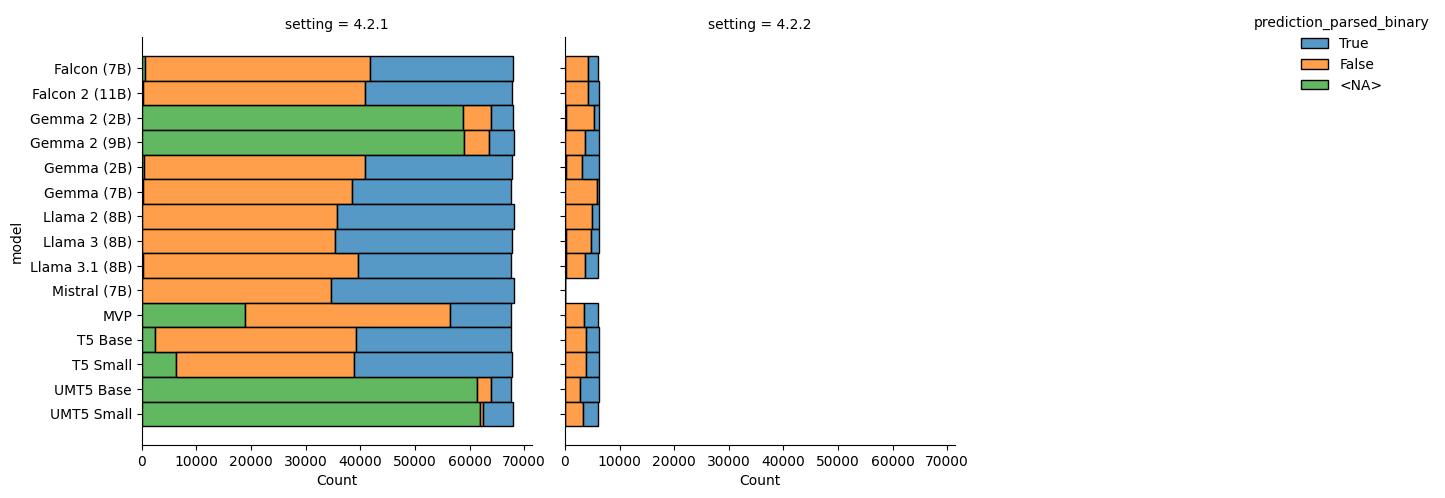

In [20]:
ax = sns.displot(
    data=joined[joined["answer_type"] == "binary"].astype(
        {"prediction_parsed_binary": "str"}
    ),
    y="model",
    col="setting",
    col_wrap=2,
    hue="prediction_parsed_binary",
    multiple="stack",
)
sns.move_legend(ax, bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
pass

In [21]:
# The ones we were not able to parse are:
joined.loc[
    (joined["answer_type"] == "binary") & (joined["prediction_parsed_binary"].isna()),
    "prediction_text",
].value_counts(dropna=False)

prediction_text
<NA>                                                                156019
-                                                                     6006
sh the a with                                                         2352
sh a the with                                                         2139
thesh a with                                                          1744
                                                                     ...  
odon Cym<0x09>.----                                                      1
person is bowing. This is the first action done by the person at         1
er is bowing is the first action done by the person at the end           1
阄åter  lyderappeti                                                       1
skipping rope, golfing (swinging a club)                                 1
Name: count, Length: 46693, dtype: int64

### Multi

In [22]:
joined[joined["answer_type"] == "multi"]["prediction_text"].value_counts(dropna=False)[
    :50
]

prediction_text
<NA>                                    109162
3                                        30191
2                                        29558
1                                        28203
shaking hands                            28054
waving                                   27690
skipping rope                            25429
eating with the right hand               25056
dancing                                  24453
punching                                 24234
golfing (swinging a club)                23936
catching a ball                          23930
drinking with the left hand              23915
picking something up with both hands     23550
bowing                                   23144
playing guitar                           22919
throwing a ball                          22181
sitting down                             20907
holding a baby                           20900
kicking a ball                           20452
jumping once                             198

In [23]:
joined[joined["answer_type"] == "multi"]["options"][:5]

0                        {'A': '1', 'B': '2', 'C': '4'}
1     {'A': 'holding a baby', 'B': 'skipping rope', ...
2     {'A': 'throwing a ball', 'B': 'T-posing', 'C':...
7     {'A': 'drinking with the left hand', 'B': 'cat...
19    {'A': 'picking something up with both hands', ...
Name: options, dtype: object

In [24]:
joined[joined["answer_type"] == "multi"]["prediction_text"]

0                                             2
1                                holding a baby
2                                playing guitar
7                   drinking with the left hand
19         picking something up with both hands
                           ...                 
2684989                          kicking a ball
2684992                                       3
2684994                         catching a ball
2684997                            jumping once
2684999                                  waving
Name: prediction_text, Length: 776274, dtype: object

In [25]:
def parse(row: dict[str, Any]) -> str | None:
    if pd.isna(row["prediction_text"]):
        return pd.NA

    value = row["prediction_text"].upper()

    match value:
        case "A" | "B" | "C":
            return value
    # else, we need to parse the options:

    # options are a dict, we want to find the key to the closest value match
    options = row["options"]
    if not options:
        raise ValueError(f"Missing options for {row}")

    # closest_key = min(options, key=lambda k: abs(len(value) - len(options[k])))

    # Now, we use exact matching to get the key
    return next((k for k, v in options.items() if v.upper() == value), pd.NA)


# Derive a new parsed column from each row
joined.loc[joined["answer_type"] == "multi", "prediction_parsed_multi"] = joined[
    joined["answer_type"] == "multi"
].apply(parse, axis="columns")

# We parsed:
joined.loc[joined["answer_type"] == "multi", "prediction_parsed_multi"].value_counts(
    dropna=False
)

prediction_parsed_multi
<NA>    221157
A       190311
B       184185
C       180621
Name: count, dtype: int64

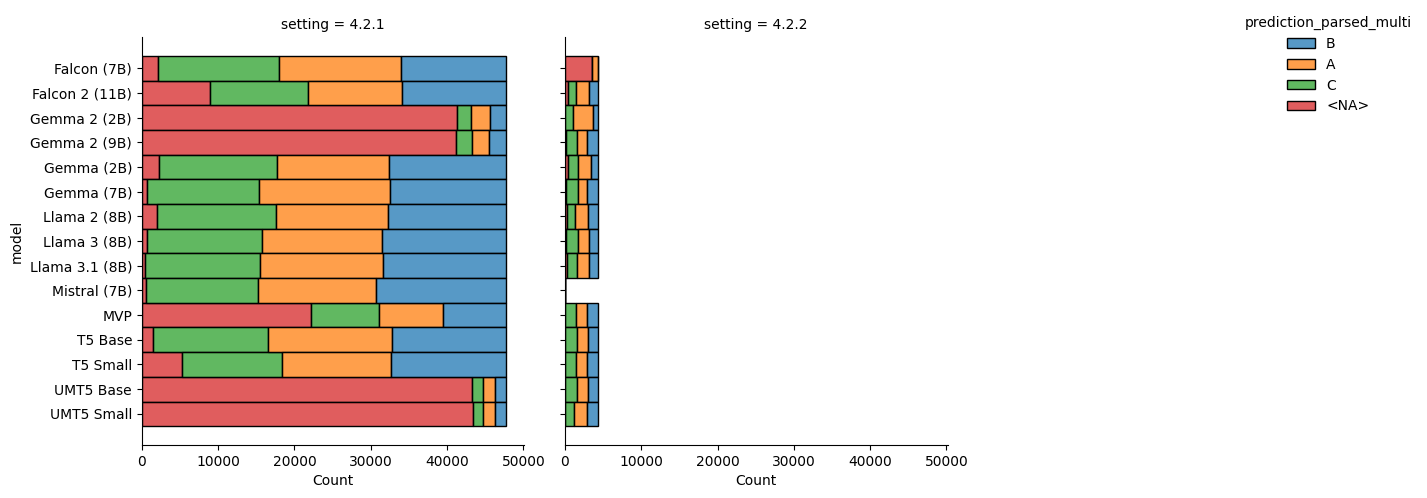

In [26]:
ax = sns.displot(
    data=joined[(joined["answer_type"] == "multi")].astype(
        {"prediction_parsed_multi": "str"}
    ),
    y="model",
    col="setting",
    col_wrap=2,
    hue="prediction_parsed_multi",
    multiple="stack",
)
sns.move_legend(ax, bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
pass

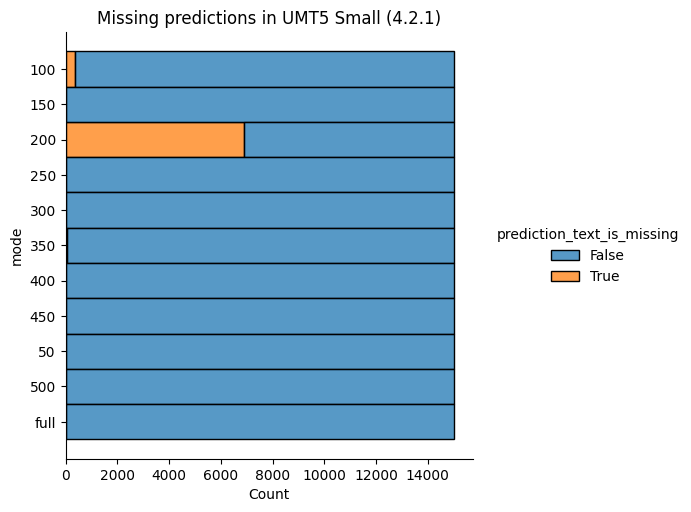

In [28]:
# joined_with_missing = joined[joined["prediction_text"].isna()]
joined_with_missing = joined.copy()
joined_with_missing = joined_with_missing[joined_with_missing["setting"] == "4.2.1"]
joined_with_missing = joined_with_missing[joined_with_missing["model"] == "UMT5 Small"]
joined_with_missing["prediction_text_is_missing"] = joined_with_missing[
    "prediction_text"
].isna()

ax = sns.displot(
    data=joined_with_missing.astype({"prediction_text_is_missing": "str"}),
    y="mode",
    hue="prediction_text_is_missing",
    multiple="stack",
)
ax.set(title="Missing predictions in UMT5 Small (4.2.1)")
sns.despine()
pass

In [29]:
# The ones we were not able to parse are:
joined.loc[
    (joined["answer_type"] == "multi") & (joined["prediction_parsed_multi"].isna()),
    "prediction_text",
].value_counts(dropna=False)[:50]

prediction_text
<NA>                                     109162
correct                                    5414
False                                      4348
-                                          4040
sh the a with                              1637
sh a the with                              1491
waving                                     1312
ball                                       1306
thesh a with                               1198
0 times                                    1188
                                           1114
shaking hands                              1094
punching                                    826
hand                                        700
dancing                                     690
bowing                                      664
1 times                                     660
the the                                     633
Admission                                   628
throwing a ball                             606
drinking with the left h

### Open

In [30]:
joined[joined["answer_type"] == "open"]["prediction_text"].value_counts(dropna=False)[
    :50
]

prediction_text
<NA>                                                                                       113838
1                                                                                           56499
2                                                                                           37596
punching                                                                                    21779
waving                                                                                      21004
skipping rope                                                                               20383
bowing                                                                                      19208
dancing                                                                                     18933
kicking a ball                                                                              18416
shaking hands                                                                               18395
drin

# Store them

In [31]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2685000 entries, 0 to 2684999
Data columns (total 17 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   setting                   object 
 1   model                     object 
 2   mode                      object 
 3   sample_id                 int64  
 4   question_id               int64  
 5   prediction_text           object 
 6   action_sequence           object 
 7   textual_description       object 
 8   question_type             object 
 9   question                  object 
 10  answer_type               object 
 11  answer_text               object 
 12  answer                    float64
 13  options                   object 
 14  options_sequence          object 
 15  prediction_parsed_binary  object 
 16  prediction_parsed_multi   object 
dtypes: float64(1), int64(2), object(14)
memory usage: 348.2+ MB


In [32]:
# joined.to_parquet(base / "all_joined.parquet")  # Somehow gave an error
joined.to_hdf(base / "all_joined.h5", key="data", mode="w")

/tmp/ipykernel_1561/2291109138.py:2: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['setting', 'model', 'mode', 'prediction_text', 'action_sequence',
       'textual_description', 'question_type', 'question', 'answer_type',
       'answer_text', 'options', 'options_sequence',
       'prediction_parsed_binary', 'prediction_parsed_multi'],
      dtype='object')]

  joined.to_hdf(base / "all_joined.h5", key="data", mode="w")
